In [84]:
import pandas as pd

In [85]:
df = pd.read_csv('df_twitter.csv')

In [86]:
df.drop(columns=['Content_cleaned', 'Content_cleaned_2', 'In Reply To Normalized',
                      'Author_Normalized', ], inplace=True)

In [87]:
df.columns

Index(['Author', 'Content', 'Date', 'Location', 'Number of Likes',
       'Number of Retweets', 'In Reply To', 'Author Name',
       'Author Description', 'Author Statuses Count',
       'Author Favourites Count', 'Author Friends Count',
       'Author Followers Count', 'Author Listed Count', 'Author Verified',
       'Mentions', 'Hashtags', 'Seed_Set_1', 'Seed_Set_2', 'Seed_Set_2_Prob',
       'Seed_Set_2_Model', 'Seed_Set_3', 'Entidad', 'Prob entidad',
       'Polaridad', 'Fecha', 'Sentimiento'],
      dtype='object')

In [88]:
"""
Segun la expo de Karen:

Raw text -> Tokenization -> Normalization -> Noise removal -> Stop word removal 
-> Lemmatization/Stemming -> Processed text
"""

'\nSegun la expo de Karen:\n\nRaw text -> Tokenization -> Normalization -> Noise removal -> Stop word removal \n-> Lemmatization/Stemming -> Processed text\n'

In [89]:
import pandas as pd
import re
import unicodedata

# =======================
# 1. NORMALIZAR TEXTO
# =======================

def normalizar(texto):
    if not isinstance(texto, str):
        return ""

    # a minúsculas
    texto = texto.lower()

    # eliminar tildes
    texto = ''.join(
        c for c in unicodedata.normalize('NFKD', texto)
        if not unicodedata.combining(c)
    )

    # eliminar URLs
    texto = re.sub(r"http\S+|www\.\S+", "", texto)

    # eliminar emojis y caracteres raros
    texto = re.sub(r"[^\w\s]", " ", texto)

    return texto


# =======================
# 2. PATRONES REGEX
# =======================

regex_tapabocas = re.compile(
    r"\b(?:tapaboca[s]?|mascarill[ao]s?|cubreboca[s]?|barbijo[s]?|proteccion\s+respiratoria)\b"
)

regex_desinfectante = re.compile(
    r"\b(?:alcohol\s*(?:en)?\s*gel|gel\s+antibacterial|antibacterial|desinfectante[s]?|sanitizer)\b"
)

regex_lavado_manos = re.compile(
    r"\b(?:lavarse\s+las\s+manos|lavado\s+de\s+manos|higiene\s+de\s+manos|lavar\s+las\s+manos)\b"
)



# =======================
# 3. APLICAR A DATAFRAME
# =======================
df["Content_norm"] = df["Content"].astype(str).apply(normalizar)

df["is_tapabocas"] = df["Content_norm"].str.contains(regex_tapabocas, regex=True)
df["is_desinfectante"] = df["Content_norm"].str.contains(regex_desinfectante, regex=True)
df["is_lavado_manos"] = df["Content_norm"].str.contains(regex_lavado_manos, regex=True)

In [90]:
df[["Content", "is_tapabocas", "is_desinfectante", "is_lavado_manos"]]

,Content,is_tapabocas,is_desinfectante,is_lavado_manos
0,VÍDEO| Reos que no están contagiados con COVID...,False,False,False
1,@IvanDuque @jaimepumarejo ya se enteraron de l...,False,False,False
2,El calvario de una familia en Cali por su mamá...,False,False,False
3,"Normas que deberán cumplirse en las empresas, ...",False,False,False
4,#Local Gestionan regidores cajas para intubaci...,False,False,False
...,...,...,...,...
151419,@patriciatraik @CCuadradoN A este gobierno no ...,False,False,False
151420,@CorpoelecMiran1 \n te informa como prevenir e...,False,False,False
151421,Dr Francisco Duran #Cuba Por Provincias ayer H...,False,False,False
151422,@GobCDMX @FondesoCDMX @SedecoCDMX Hola me podr...,False,False,False


ANÁLISIS DE PROPORCIONES POR TIEMPO

📊 Preprocesando datos...
✅ Rango de fechas: 2020-03-31 00:00:00 a 2020-08-18 00:00:00
✅ Total de registros: 151424
✅ Número de entidades únicas: 8
✅ Entidades: ['Noticias locales, nacionales o globales' 'Sin descripción'
 'Doctor o profesional de salud' 'Autoridad local de salud o gobierno'
 'Líder cultural, religioso o comunitario' 'Literatura científica'
 'Líder nacional' 'Organización Mundial de la Salud']

ANÁLISIS DIARIO

📈 Resumen diario (últimos 5 días):
Entidad     Autoridad local de salud o gobierno  \
Fecha_dia                                         
2020-08-14                             0.180249   
2020-08-15                             0.214729   
2020-08-16                             0.186909   
2020-08-17                             0.174960   
2020-08-18                             0.140000   

Entidad     Doctor o profesional de salud  Literatura científica  \
Fecha_dia                                                          
202

c:\Users\afpue\AppData\Local\Programs\Python\Python314\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 128197 (\N{CALENDAR}) missing from font(s) Arial.
  fig.canvas.draw()
c:\Users\afpue\AppData\Local\Programs\Python\Python314\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  fig.canvas.draw()
C:\Users\afpue\AppData\Local\Temp\ipykernel_1796\112775468.py:150: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\afpue\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128197 (\N{CALENDAR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\afpue\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\afpue\AppData\Roaming\Python\Python314\site-packages\IPython

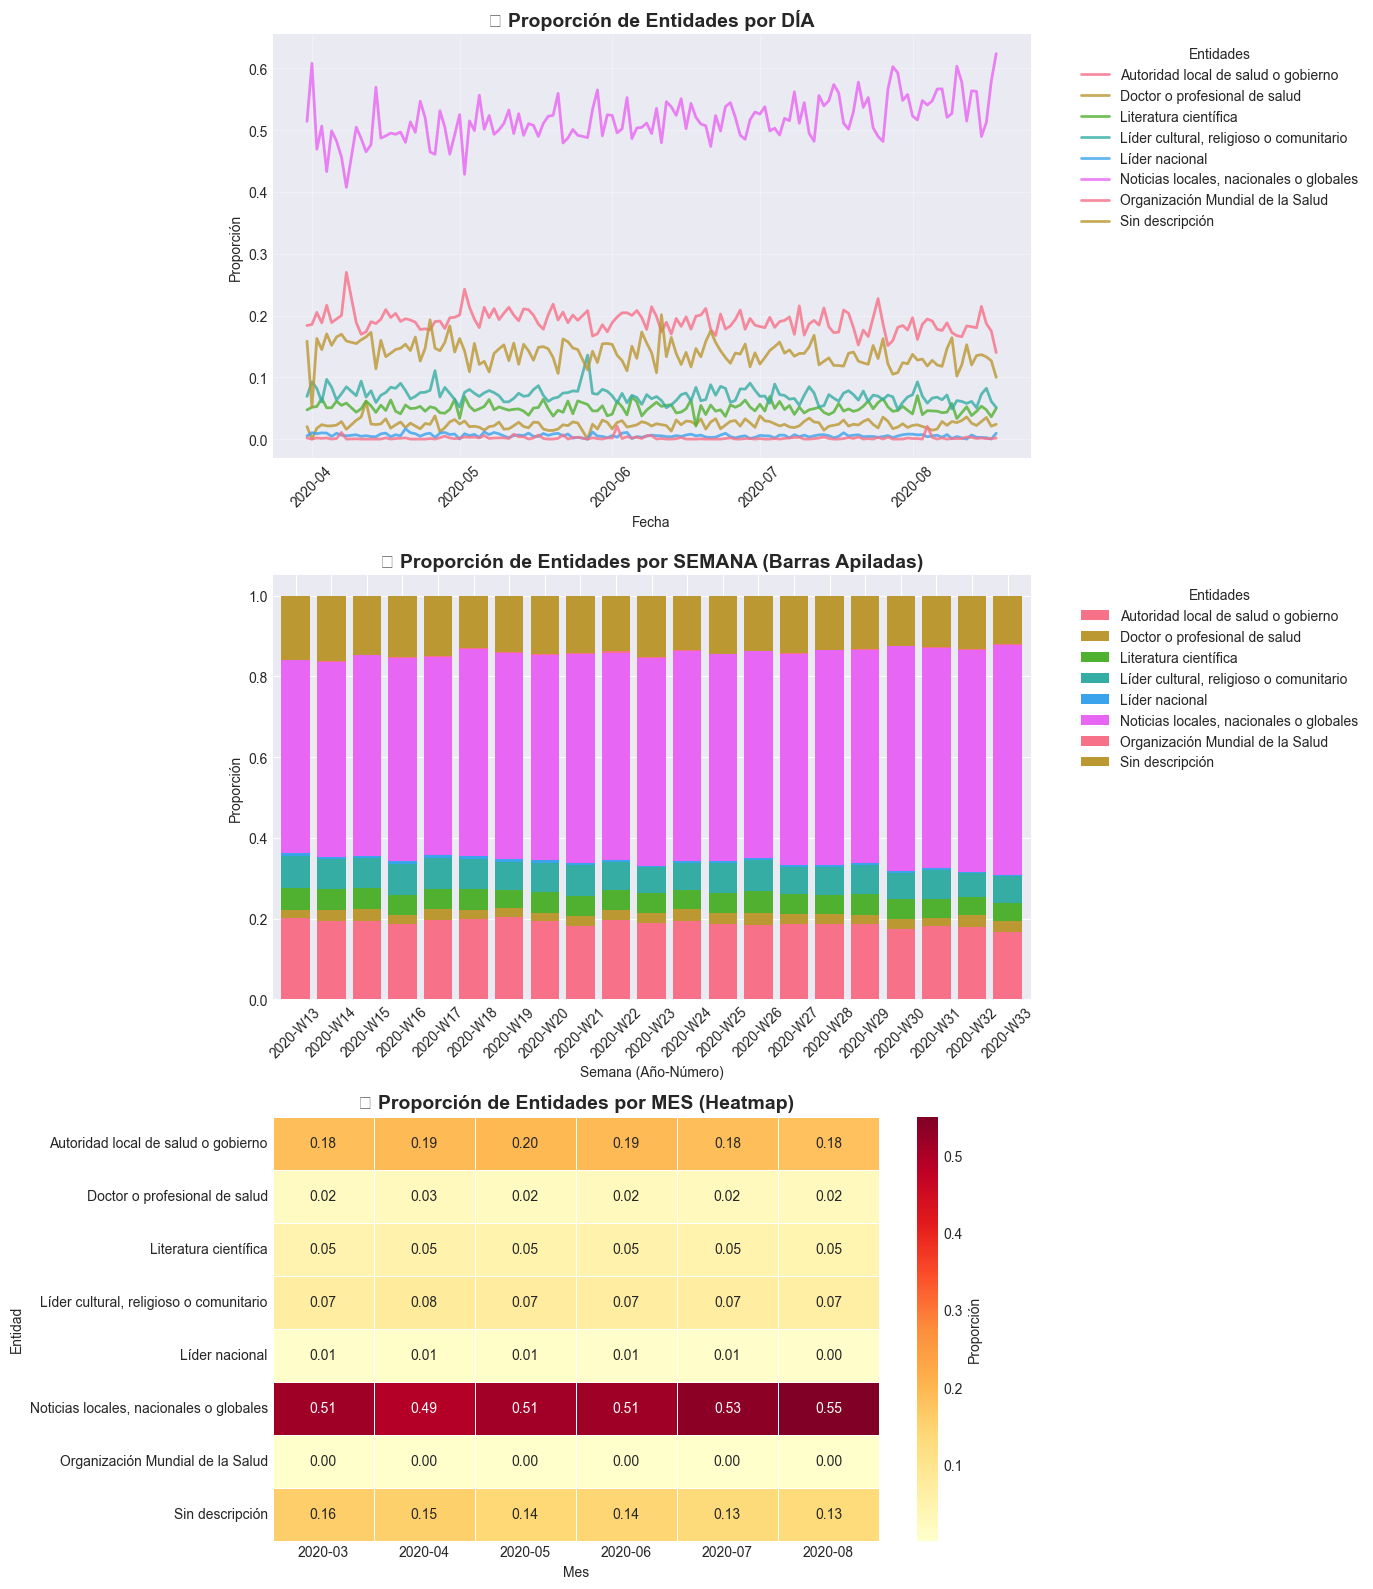


TABLA RESUMEN FINAL

📋 Resumen completo por entidad:
                                                                         Entidad  Proporción_Promedio_Semanal  Proporción_Máxima_Semanal  Proporción_Mínima_Semanal  Proporción_Promedio_Diaria  Tendencia_Semanal
Entidad                                                                                                                                                                                                           
Noticias locales, nacionales o globales  Noticias locales, nacionales o globales                     0.517984                   0.570137                   0.476005                    0.517770           0.094132
Autoridad local de salud o gobierno          Autoridad local de salud o gobierno                     0.189310                   0.204168                   0.167915                    0.190401          -0.033684
Sin descripción                                                  Sin descripción                     0

In [97]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ======================
# 1. CONFIGURACIÓN INICIAL
# ======================
print("="*50)
print("ANÁLISIS DE PROPORCIONES POR TIEMPO")
print("="*50)

# Verificar que tenemos las columnas necesarias
if "Fecha" not in df.columns or "Entidad" not in df.columns:
    print("❌ ERROR: El DataFrame debe tener columnas 'Fecha' y 'Entidad'")
else:
    # ======================
    # 2. PREPROCESAMIENTO
    # ======================
    print("\n📊 Preprocesando datos...")
    
    # Convertir fecha a datetime
    df["Fecha"] = pd.to_datetime(df["Fecha"])
    
    # Crear nuevas columnas para agrupación
    df["Fecha_dia"] = df["Fecha"].dt.date
    df["Año_Semana"] = df["Fecha"].dt.strftime('%Y-W%U')  # Formato: 2023-W45
    df["Año_Mes"] = df["Fecha"].dt.strftime('%Y-%m')     # Formato: 2023-11
    
    print(f"✅ Rango de fechas: {df['Fecha'].min()} a {df['Fecha'].max()}")
    print(f"✅ Total de registros: {len(df)}")
    print(f"✅ Número de entidades únicas: {df['Entidad'].nunique()}")
    print(f"✅ Entidades: {df['Entidad'].unique()[:10]}")  # Muestra las primeras 10
    
    # ======================
    # 3. ANÁLISIS POR DÍA
    # ======================
    print("\n" + "="*50)
    print("ANÁLISIS DIARIO")
    print("="*50)
    
    # Tabla de frecuencias diarias
    frecuencia_diaria = pd.crosstab(df["Fecha_dia"], df["Entidad"])
    
    # Proporciones diarias
    proporcion_diaria = frecuencia_diaria.div(frecuencia_diaria.sum(axis=1), axis=0)
    
    # Estadísticas resumidas
    print("\n📈 Resumen diario (últimos 5 días):")
    print(proporcion_diaria.tail())
    
    print(f"\n📊 Media de proporciones por entidad (diaria):")
    print(proporcion_diaria.mean().sort_values(ascending=False))
    
    # ======================
    # 4. ANÁLISIS POR SEMANA
    # ======================
    print("\n" + "="*50)
    print("ANÁLISIS SEMANAL")
    print("="*50)
    
    # Tabla de frecuencias semanales
    frecuencia_semanal = pd.crosstab(df["Año_Semana"], df["Entidad"])
    
    # Proporciones semanales
    proporcion_semanal = frecuencia_semanal.div(frecuencia_semanal.sum(axis=1), axis=0)
    
    # Ordenar por semana
    proporcion_semanal = proporcion_semanal.sort_index()
    
    print("\n📈 Resumen semanal (últimas 5 semanas):")
    print(proporcion_semanal.tail())
    
    print(f"\n📊 Media de proporciones por entidad (semanal):")
    print(proporcion_semanal.mean().sort_values(ascending=False))
    
    # ======================
    # 5. ANÁLISIS POR MES (EXTRA)
    # ======================
    print("\n" + "="*50)
    print("ANÁLISIS MENSUAL (EXTRA)")
    print("="*50)
    
    frecuencia_mensual = pd.crosstab(df["Año_Mes"], df["Entidad"])
    proporcion_mensual = frecuencia_mensual.div(frecuencia_mensual.sum(axis=1), axis=0)
    
    print("\n📈 Resumen mensual:")
    print(proporcion_mensual)
    
    # ======================
    # 6. VISUALIZACIONES
    # ======================
    print("\n" + "="*50)
    print("GENERANDO VISUALIZACIONES...")
    print("="*50)
    
    # Configurar estilo de gráficos
    plt.style.use('seaborn-v0_8-darkgrid')
    sns.set_palette("husl")
    
    # Crear figura con subplots
    fig, axes = plt.subplots(3, 1, figsize=(14, 16))
    
    # ----- GRÁFICO 1: Proporciones diarias -----
    ax1 = axes[0]
    for entidad in proporcion_diaria.columns:
        ax1.plot(proporcion_diaria.index, proporcion_diaria[entidad], 
                label=entidad, linewidth=2, alpha=0.8)
    
    ax1.set_title('📅 Proporción de Entidades por DÍA', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Fecha')
    ax1.set_ylabel('Proporción')
    ax1.legend(title='Entidades', bbox_to_anchor=(1.05, 1), loc='upper left')
    ax1.grid(True, alpha=0.3)
    ax1.tick_params(axis='x', rotation=45)
    
    # ----- GRÁFICO 2: Proporciones semanales (gráfico de barras apiladas) -----
    ax2 = axes[1]
    proporcion_semanal.plot(kind='bar', stacked=True, ax=ax2, width=0.8)
    
    ax2.set_title('📊 Proporción de Entidades por SEMANA (Barras Apiladas)', 
                 fontsize=14, fontweight='bold')
    ax2.set_xlabel('Semana (Año-Número)')
    ax2.set_ylabel('Proporción')
    ax2.legend(title='Entidades', bbox_to_anchor=(1.05, 1), loc='upper left')
    ax2.tick_params(axis='x', rotation=45)
    
    # ----- GRÁFICO 3: Proporciones mensuales (heatmap) -----
    ax3 = axes[2]
    
    # Si hay muchas entidades, mostramos solo las top 10
    if proporcion_mensual.shape[1] > 10:
        top_entidades = proporcion_mensual.mean().nlargest(10).index
        data_heatmap = proporcion_mensual[top_entidades]
    else:
        data_heatmap = proporcion_mensual
    
    sns.heatmap(data_heatmap.T,  # Transponer para mejor visualización
                ax=ax3, 
                cmap='YlOrRd',
                annot=True, 
                fmt='.2f',
                linewidths=0.5,
                cbar_kws={'label': 'Proporción'})
    
    ax3.set_title('🔥 Proporción de Entidades por MES (Heatmap)', 
                 fontsize=14, fontweight='bold')
    ax3.set_xlabel('Mes')
    ax3.set_ylabel('Entidad')
    
    plt.tight_layout()
    plt.show()
    
    # ======================
    # 7. TABLA RESUMEN FINAL
    # ======================
    print("\n" + "="*50)
    print("TABLA RESUMEN FINAL")
    print("="*50)
    
    # Crear tabla resumen
    resumen = pd.DataFrame({
        'Entidad': proporcion_semanal.columns,
        'Proporción_Promedio_Semanal': proporcion_semanal.mean().values,
        'Proporción_Máxima_Semanal': proporcion_semanal.max().values,
        'Proporción_Mínima_Semanal': proporcion_semanal.min().values,
        'Proporción_Promedio_Diaria': proporcion_diaria.mean().values,
        'Tendencia_Semanal': proporcion_semanal.iloc[-1] - proporcion_semanal.iloc[0]  # Cambio entre primera y última semana
    })
    
    # Ordenar por proporción promedio semanal
    resumen = resumen.sort_values('Proporción_Promedio_Semanal', ascending=False)
    
    print("\n📋 Resumen completo por entidad:")
    print(resumen.to_string())
    
    # ======================
    # 8. EXPORTAR RESULTADOS (OPCIONAL)
    # ======================
    print("\n" + "="*50)
    print("OPCIONES DE EXPORTACIÓN")
    print("="*50)
    
    # Preguntar si desea exportar
    exportar = input("\n¿Deseas exportar los resultados a Excel? (s/n): ")
    
    if exportar.lower() == 's':
        # Crear un archivo Excel con múltiples hojas
        with pd.ExcelWriter('analisis_proporciones.xlsx', engine='openpyxl') as writer:
            proporcion_diaria.to_excel(writer, sheet_name='Diario')
            proporcion_semanal.to_excel(writer, sheet_name='Semanal')
            proporcion_mensual.to_excel(writer, sheet_name='Mensual')
            resumen.to_excel(writer, sheet_name='Resumen', index=False)
        
        print("✅ Archivo 'analisis_proporciones.xlsx' exportado exitosamente!")
        print("   Contiene 4 hojas: Diario, Semanal, Mensual y Resumen")
    
    print("\n" + "="*50)
    print("ANÁLISIS COMPLETADO ✅")
    print("="*50)

In [99]:
df["Polaridad"].unique()

array(['Neutra', 'Negativa', 'Positiva'], dtype=object)

ANÁLISIS DE POLARIDAD CATEGÓRICA POR ENTIDAD EN EL TIEMPO

📊 Preprocesando datos y mapeando polaridad...
📈 Valores únicos en Polaridad: ['Neutra' 'Negativa' 'Positiva']
📊 Distribución inicial:
Polaridad
Neutra      70160
Negativa    66834
Positiva    14430
Name: count, dtype: int64

✅ Verificación de mapeo:
  Polaridad  Polaridad_Num
0    Neutra              0
1  Negativa             -1
2  Negativa             -1
3    Neutra              0
4    Neutra              0
5    Neutra              0
6  Negativa             -1
7  Negativa             -1
8    Neutra              0
9    Neutra              0

📊 Distribución después del mapeo:
Polaridad_Num
-1    66834
 0    70160
 1    14430
Name: count, dtype: int64

✅ Datos procesados:
   Total de registros: 151424
   Rango de fechas: 2020-03-31 00:00:00 a 2020-08-18 00:00:00
   Número de entidades únicas: 8

ANÁLISIS GLOBAL DE POLARIDAD POR ENTIDAD

📊 Top 10 entidades con mejor polaridad (Score Normalizado):
                                  

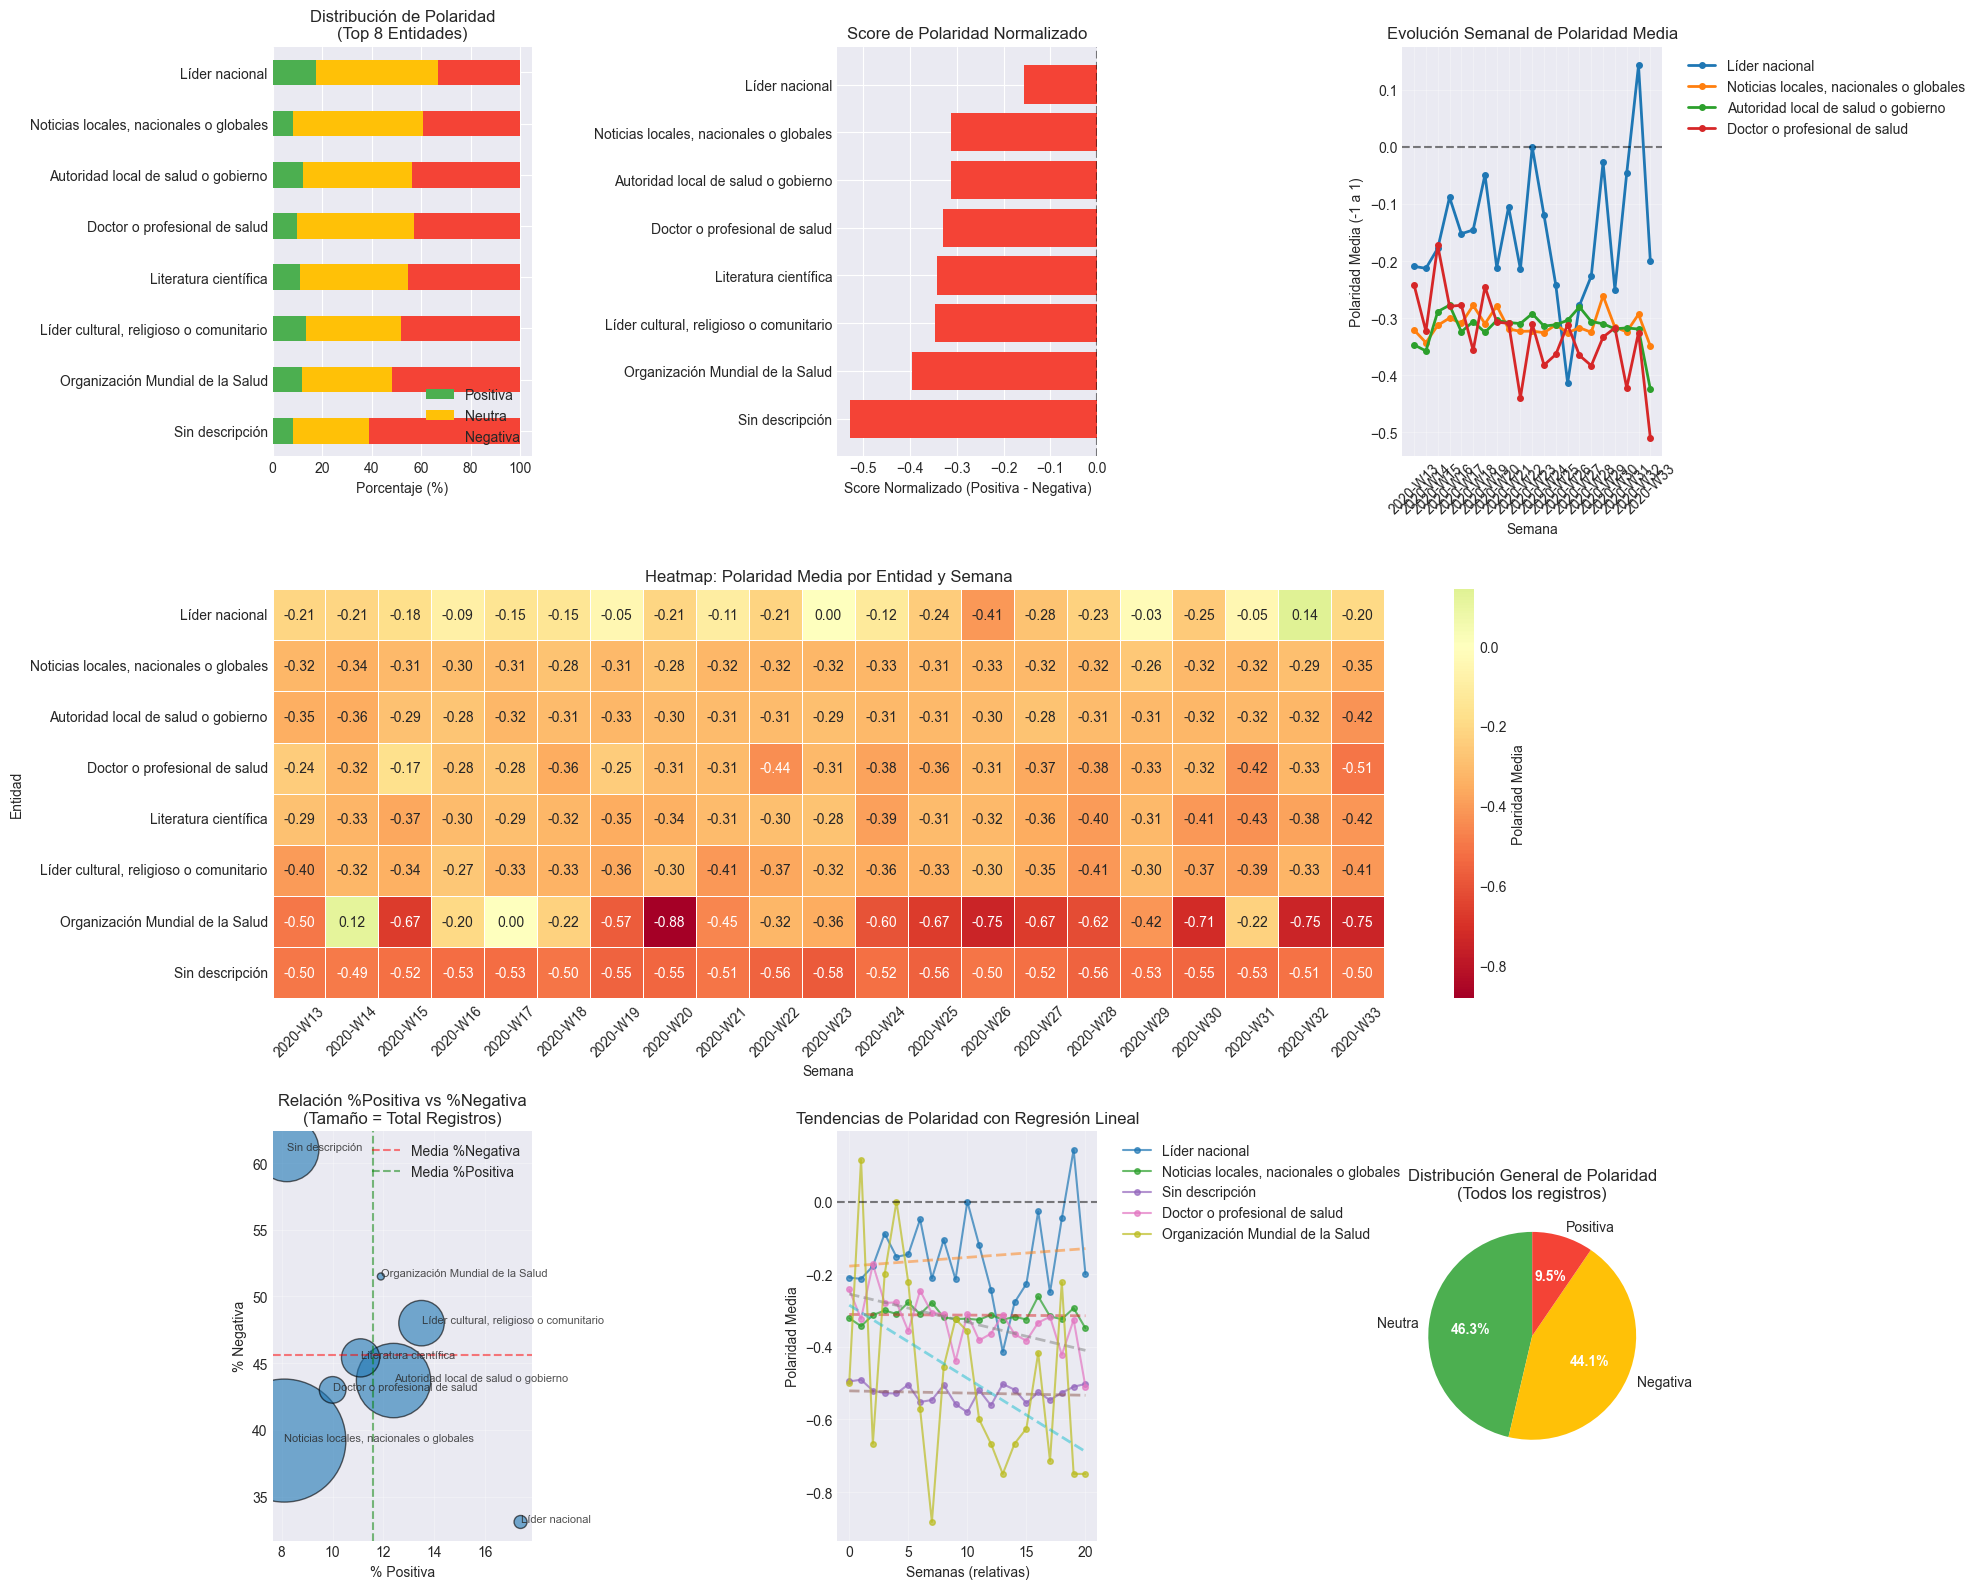


ANÁLISIS DE POLARIDAD POR DÍA DE LA SEMANA

📊 Polaridad por día de la semana:
             mean  count    std
Dia_Semana                     
Monday     -0.338  21659  0.638
Tuesday    -0.322  21758  0.643
Wednesday  -0.329  19145  0.640
Thursday   -0.321  22186  0.643
Friday     -0.333  23404  0.651
Saturday   -0.373  19282  0.648
Sunday     -0.403  23990  0.651


C:\Users\afpue\AppData\Local\Temp\ipykernel_1796\3585093670.py:415: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  polaridad_dia_semana = df_clean.groupby('Dia_Semana')['Polaridad_Num'].agg(['mean', 'count', 'std']).round(3)


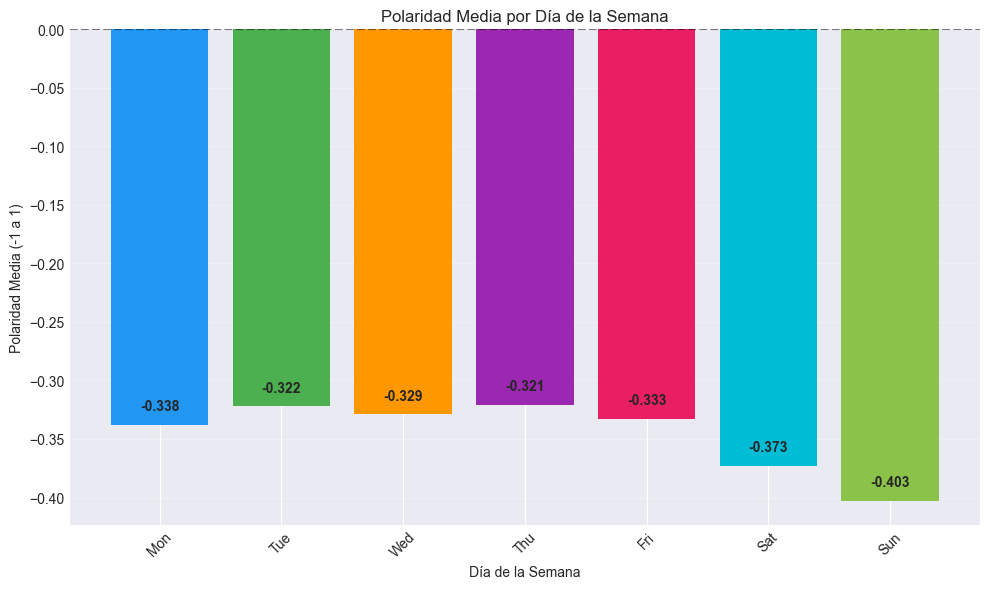


RESUMEN Y OPCIONES DE EXPORTACIÓN

📋 RESUMEN EJECUTIVO:
   • Total registros analizados: 151424
   • Número de entidades únicas: 8
   • Distribución global: {'Neutra': np.int64(70160), 'Negativa': np.int64(66834), 'Positiva': np.int64(14430)}

🏆 MEJOR ENTIDAD: Líder nacional
   • Score: -0.157
   • % Positiva: 17.4%
   • % Negativa: 33.1%

⚠️ PEOR ENTIDAD: Sin descripción
   • Score: -0.529
   • % Positiva: 8.2%
   • % Negativa: 61.0%

📈 TENDENCIAS DESTACADAS:
   • Entidades con mayor mejora: Líder nacional, Noticias locales, nacionales o globales, Sin descripción
   • Entidades con mayor empeoramiento: Literatura científica, Doctor o profesional de salud, Organización Mundial de la Salud

ANÁLISIS COMPLETADO ✅


In [100]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# ======================
# 1. CONFIGURACIÓN INICIAL
# ======================
print("="*60)
print("ANÁLISIS DE POLARIDAD CATEGÓRICA POR ENTIDAD EN EL TIEMPO")
print("="*60)

# Verificar columnas necesarias
required_columns = ["Fecha", "Entidad", "Polaridad"]
missing_columns = [col for col in required_columns if col not in df.columns]

if missing_columns:
    print(f"❌ ERROR: Faltan columnas: {missing_columns}")
    print(f"   Columnas disponibles: {list(df.columns)}")
else:
    # ======================
    # 2. PREPROCESAMIENTO Y MAPEO
    # ======================
    print("\n📊 Preprocesando datos y mapeando polaridad...")
    
    # Convertir fecha a datetime
    df["Fecha"] = pd.to_datetime(df["Fecha"])
    
    # Mostrar valores únicos
    print(f"📈 Valores únicos en Polaridad: {df['Polaridad'].unique()}")
    print(f"📊 Distribución inicial:")
    print(df["Polaridad"].value_counts())
    
    # Crear copia para trabajar
    df_clean = df.copy()
    
    # Mapear polaridad a valores numéricos
    # Opción 1: Escala -1, 0, 1 (recomendado)
    polaridad_map = {
        'Negativa': -1,
        'Neutra': 0,
        'Positiva': 1
    }
    
    # Opción 2: Escala 0, 1, 2 (para ciertos análisis)
    polaridad_map_alt = {
        'Negativa': 0,
        'Neutra': 1,
        'Positiva': 2
    }
    
    # Aplicar mapeo principal (-1, 0, 1)
    df_clean["Polaridad_Num"] = df_clean["Polaridad"].map(polaridad_map)
    
    # Verificar mapeo
    print(f"\n✅ Verificación de mapeo:")
    print(df_clean[["Polaridad", "Polaridad_Num"]].head(10))
    print(f"\n📊 Distribución después del mapeo:")
    print(df_clean["Polaridad_Num"].value_counts().sort_index())
    
    # Crear nuevas columnas para agrupación
    df_clean["Fecha_dia"] = df_clean["Fecha"].dt.date
    df_clean["Año_Semana"] = df_clean["Fecha"].dt.strftime('%Y-W%U')
    df_clean["Año_Mes"] = df_clean["Fecha"].dt.strftime('%Y-%m')
    df_clean["Mes"] = df_clean["Fecha"].dt.month
    df_clean["Dia_Semana"] = df_clean["Fecha"].dt.day_name()
    
    print(f"\n✅ Datos procesados:")
    print(f"   Total de registros: {len(df_clean)}")
    print(f"   Rango de fechas: {df_clean['Fecha'].min()} a {df_clean['Fecha'].max()}")
    print(f"   Número de entidades únicas: {df_clean['Entidad'].nunique()}")
    
    # ======================
    # 3. ANÁLISIS GLOBAL DE POLARIDAD POR ENTIDAD
    # ======================
    print("\n" + "="*60)
    print("ANÁLISIS GLOBAL DE POLARIDAD POR ENTIDAD")
    print("="*60)
    
    # Calcular métricas por entidad
    polaridad_stats = {}
    
    for entidad in df_clean["Entidad"].unique():
        mask = df_clean["Entidad"] == entidad
        subset = df_clean[mask]
        
        # Conteos por categoría
        counts = subset["Polaridad"].value_counts()
        
        # Estadísticas numéricas
        polaridad_numeric = subset["Polaridad_Num"]
        
        polaridad_stats[entidad] = {
            'Total': len(subset),
            'Positiva': counts.get('Positiva', 0),
            'Neutra': counts.get('Neutra', 0),
            'Negativa': counts.get('Negativa', 0),
            '%_Positiva': round(counts.get('Positiva', 0) / len(subset) * 100, 1),
            '%_Neutra': round(counts.get('Neutra', 0) / len(subset) * 100, 1),
            '%_Negativa': round(counts.get('Negativa', 0) / len(subset) * 100, 1),
            'Polaridad_Media': round(polaridad_numeric.mean(), 3),
            'Polaridad_Std': round(polaridad_numeric.std(), 3),
            'Score_Normalizado': round((counts.get('Positiva', 0) - counts.get('Negativa', 0)) / len(subset), 3),
            'Ratio_Pos_Neg': round(counts.get('Positiva', 1) / counts.get('Negativa', 1), 2) if counts.get('Negativa', 0) > 0 else float('inf')
        }
    
    # Convertir a DataFrame
    df_stats = pd.DataFrame(polaridad_stats).T
    
    # Ordenar por Score Normalizado (Positiva - Negativa)
    df_stats_sorted = df_stats.sort_values('Score_Normalizado', ascending=False)
    
    print("\n📊 Top 10 entidades con mejor polaridad (Score Normalizado):")
    print(df_stats_sorted[['Total', '%_Positiva', '%_Neutra', '%_Negativa', 'Score_Normalizado']].head(10))
    
    print("\n📉 Top 10 entidades con peor polaridad (Score Normalizado):")
    print(df_stats_sorted[['Total', '%_Positiva', '%_Neutra', '%_Negativa', 'Score_Normalizado']].tail(10))
    
    # ======================
    # 4. ANÁLISIS TEMPORAL POR ENTIDAD - SEMANAL
    # ======================
    print("\n" + "="*60)
    print("ANÁLISIS SEMANAL DE POLARIDAD POR ENTIDAD")
    print("="*60)
    
    # Para análisis temporal, agrupamos por semana y entidad
    polaridad_semanal = {}
    
    # Procesar cada entidad
    for entidad in df_clean["Entidad"].unique()[:15]:  # Limitar a 15 para no saturar
        mask = df_clean["Entidad"] == entidad
        subset = df_clean[mask]
        
        # Agrupar por semana
        weekly = subset.groupby("Año_Semana").agg({
            'Polaridad_Num': ['mean', 'count'],
            'Polaridad': lambda x: (x == 'Positiva').sum() / len(x) * 100  # % positivo
        })
        
        weekly.columns = ['Polaridad_Media', 'Conteo', '%_Positivo']
        weekly['Entidad'] = entidad
        
        polaridad_semanal[entidad] = weekly
    
    # Combinar todos los datos semanales
    all_weekly = pd.concat(polaridad_semanal.values())
    
    # Resetear índice para tener 'Año_Semana' como columna
    all_weekly = all_weekly.reset_index()
    
    print("\n📈 Evolución semanal de polaridad (muestra):")
    print(all_weekly.head(10))
    
    # ======================
    # 5. ANÁLISIS DE PROPORCIONES TEMPORALES
    # ======================
    print("\n" + "="*60)
    print("PROPORCIONES DE POLARIDAD EN EL TIEMPO")
    print("="*60)
    
    # Crear tabla pivot para análisis temporal
    # Agrupar por semana y polaridad
    temporal_pivot = pd.crosstab(
        [df_clean["Año_Semana"], df_clean["Entidad"]], 
        df_clean["Polaridad"],
        normalize='index'
    ).round(3)
    
    # Resetear índice
    temporal_pivot = temporal_pivot.reset_index()
    
    print("\n📊 Proporciones semanales por entidad (ejemplo):")
    print(temporal_pivot.head(10))
    
    # ======================
    # 6. CÁLCULO DE TENDENCIAS
    # ======================
    print("\n" + "="*60)
    print("ANÁLISIS DE TENDENCIAS TEMPORALES")
    print("="*60)
    
    tendencias = {}
    
    for entidad in df_clean["Entidad"].unique()[:20]:  # Analizar primeras 20 entidades
        mask = df_clean["Entidad"] == entidad
        subset = df_clean[mask]
        
        if len(subset) >= 4:  # Mínimo 4 puntos para análisis de tendencia
            # Agrupar por semana
            weekly_trend = subset.groupby("Año_Semana")["Polaridad_Num"].mean().sort_index()
            
            if len(weekly_trend) >= 2:
                # Convertir índices a números para regresión
                x = np.arange(len(weekly_trend))
                y = weekly_trend.values
                
                # Calcular regresión lineal
                slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
                
                # Calcular cambio en porcentaje positivo
                weekly_pos = subset.groupby("Año_Semana")["Polaridad"].apply(
                    lambda x: (x == 'Positiva').sum() / len(x) * 100
                ).sort_index()
                
                if len(weekly_pos) >= 2:
                    cambio_positivo = weekly_pos.iloc[-1] - weekly_pos.iloc[0]
                else:
                    cambio_positivo = 0
                
                tendencias[entidad] = {
                    'Tendencia_Pendiente': round(slope, 4),
                    'Tendencia_Direccion': 'Mejora' if slope > 0 else 'Empeora' if slope < 0 else 'Estable',
                    'R_cuadrado': round(r_value**2, 3),
                    'P_valor': round(p_value, 4),
                    'Polaridad_Inicial': round(y[0], 3),
                    'Polaridad_Final': round(y[-1], 3),
                    'Cambio_Polaridad': round(y[-1] - y[0], 3),
                    'Cambio_%_Positivo': round(cambio_positivo, 1),
                    'Semanas_Activa': len(weekly_trend),
                    'Total_Registros': len(subset)
                }
    
    # Crear DataFrame de tendencias
    df_tendencias = pd.DataFrame(tendencias).T
    
    # Ordenar por tendencia (pendiente)
    df_tendencias_sorted = df_tendencias.sort_values('Tendencia_Pendiente', ascending=False)
    
    print("\n🔥 Top 10 entidades con mayor mejora (tendencia positiva):")
    print(df_tendencias_sorted.head(10)[['Tendencia_Pendiente', 'Tendencia_Direccion', 
                                         'Cambio_Polaridad', 'Cambio_%_Positivo']])
    
    print("\n📉 Top 10 entidades con mayor empeoramiento (tendencia negativa):")
    print(df_tendencias_sorted.tail(10)[['Tendencia_Pendiente', 'Tendencia_Direccion',
                                         'Cambio_Polaridad', 'Cambio_%_Positivo']])
    
    # ======================
    # 7. VISUALIZACIONES COMPLETAS
    # ======================
    print("\n" + "="*60)
    print("GENERANDO VISUALIZACIONES...")
    print("="*60)
    
    # Configurar estilo
    plt.style.use('seaborn-v0_8-darkgrid')
    sns.set_palette("tab10")
    
    # Seleccionar top entidades para visualización
    num_top_entidades = 8
    top_entidades = df_stats_sorted.head(num_top_entidades).index.tolist()
    
    # Crear figura principal
    fig = plt.figure(figsize=(20, 16))
    
    # ----- GRÁFICO 1: Distribución de polaridad por entidad (top) -----
    ax1 = plt.subplot(3, 3, 1)
    
    # Preparar datos para gráfico de barras apiladas
    plot_data = df_stats_sorted.head(num_top_entidades)[['%_Positiva', '%_Neutra', '%_Negativa']]
    
    plot_data.plot(kind='barh', stacked=True, ax=ax1, 
                   color=['#4CAF50', '#FFC107', '#F44336'])
    
    ax1.set_xlabel('Porcentaje (%)')
    ax1.set_title(f'Distribución de Polaridad\n(Top {num_top_entidades} Entidades)')
    ax1.legend(['Positiva', 'Neutra', 'Negativa'], loc='lower right')
    ax1.invert_yaxis()
    
    # ----- GRÁFICO 2: Score Normalizado por entidad -----
    ax2 = plt.subplot(3, 3, 2)
    
    scores = df_stats_sorted.head(15)['Score_Normalizado']
    colors = ['#4CAF50' if x > 0 else '#F44336' if x < 0 else '#FFC107' for x in scores]
    
    ax2.barh(range(len(scores)), scores.values, color=colors)
    ax2.set_yticks(range(len(scores)))
    ax2.set_yticklabels(scores.index)
    ax2.set_xlabel('Score Normalizado (Positiva - Negativa)')
    ax2.set_title('Score de Polaridad Normalizado')
    ax2.axvline(x=0, color='black', linestyle='--', alpha=0.5)
    ax2.invert_yaxis()
    
    # ----- GRÁFICO 3: Evolución temporal de polaridad media -----
    ax3 = plt.subplot(3, 3, 3)
    
    for i, entidad in enumerate(top_entidades[:4]):  # Mostrar solo 4 para claridad
        mask = (all_weekly['Entidad'] == entidad)
        subset = all_weekly[mask].sort_values('Año_Semana')
        
        if len(subset) > 0:
            ax3.plot(subset['Año_Semana'], subset['Polaridad_Media'], 
                    'o-', linewidth=2, label=entidad, markersize=4)
    
    ax3.set_xlabel('Semana')
    ax3.set_ylabel('Polaridad Media (-1 a 1)')
    ax3.set_title('Evolución Semanal de Polaridad Media')
    ax3.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax3.tick_params(axis='x', rotation=45)
    ax3.grid(True, alpha=0.3)
    ax3.axhline(y=0, color='black', linestyle='--', alpha=0.5)
    
    # ----- GRÁFICO 4: Heatmap de polaridad por entidad y semana -----
    ax4 = plt.subplot(3, 3, (4, 6))  # Ocupar 2 celdas
    
    # Preparar datos para heatmap
    heatmap_data = all_weekly[all_weekly['Entidad'].isin(top_entidades)]
    heatmap_pivot = heatmap_data.pivot_table(
        index='Entidad',
        columns='Año_Semana',
        values='Polaridad_Media',
        aggfunc='mean'
    )
    
    # Ordenar entidades por score
    heatmap_pivot = heatmap_pivot.reindex(
        df_stats_sorted[df_stats_sorted.index.isin(top_entidades)].index
    )
    
    # Crear heatmap
    sns.heatmap(heatmap_pivot, ax=ax4, cmap='RdYlGn', 
                center=0, annot=True, fmt='.2f',
                linewidths=0.5, cbar_kws={'label': 'Polaridad Media'})
    
    ax4.set_title('Heatmap: Polaridad Media por Entidad y Semana')
    ax4.set_xlabel('Semana')
    ax4.set_ylabel('Entidad')
    ax4.tick_params(axis='x', rotation=45)
    
    # ----- GRÁFICO 5: Comparación % Positivo vs % Negativo -----
    ax5 = plt.subplot(3, 3, 7)
    
    scatter_data = df_stats_sorted.head(20)
    
    ax5.scatter(scatter_data['%_Positiva'], scatter_data['%_Negativa'],
               s=scatter_data['Total']/10, alpha=0.6, edgecolors='black')
    
    # Añadir etiquetas para las principales entidades
    for i, row in scatter_data.head(8).iterrows():
        ax5.annotate(i, (row['%_Positiva'], row['%_Negativa']), 
                    fontsize=8, alpha=0.8)
    
    ax5.set_xlabel('% Positiva')
    ax5.set_ylabel('% Negativa')
    ax5.set_title('Relación %Positiva vs %Negativa\n(Tamaño = Total Registros)')
    ax5.grid(True, alpha=0.3)
    ax5.axhline(y=scatter_data['%_Negativa'].mean(), color='red', 
                linestyle='--', alpha=0.5, label='Media %Negativa')
    ax5.axvline(x=scatter_data['%_Positiva'].mean(), color='green', 
                linestyle='--', alpha=0.5, label='Media %Positiva')
    ax5.legend()
    
    # ----- GRÁFICO 6: Tendencia temporal (líneas de regresión) -----
    ax6 = plt.subplot(3, 3, 8)
    
    # Seleccionar 3 entidades con tendencias más interesantes
    entidades_tendencia = list(df_tendencias_sorted.head(3).index) + \
                         list(df_tendencias_sorted.tail(2).index)
    
    for entidad in entidades_tendencia:
        if entidad in polaridad_semanal:
            weekly_data = polaridad_semanal[entidad].sort_index()
            
            if len(weekly_data) > 1:
                # Datos
                semanas = np.arange(len(weekly_data))
                polaridades = weekly_data['Polaridad_Media'].values
                
                # Línea de tendencia
                z = np.polyfit(semanas, polaridades, 1)
                p = np.poly1d(z)
                
                # Plot
                ax6.plot(semanas, polaridades, 'o-', alpha=0.7, label=entidad, markersize=4)
                ax6.plot(semanas, p(semanas), '--', alpha=0.5, linewidth=2)
    
    ax6.set_xlabel('Semanas (relativas)')
    ax6.set_ylabel('Polaridad Media')
    ax6.set_title('Tendencias de Polaridad con Regresión Lineal')
    ax6.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax6.grid(True, alpha=0.3)
    ax6.axhline(y=0, color='black', linestyle='--', alpha=0.5)
    
    # ----- GRÁFICO 7: Distribución general de polaridad -----
    ax7 = plt.subplot(3, 3, 9)
    
    polaridad_counts = df_clean['Polaridad'].value_counts()
    colors_pie = ['#4CAF50', '#FFC107', '#F44336']
    
    wedges, texts, autotexts = ax7.pie(polaridad_counts.values, labels=polaridad_counts.index,
                                      autopct='%1.1f%%', colors=colors_pie, startangle=90)
    
    ax7.set_title('Distribución General de Polaridad\n(Todos los registros)')
    
    # Mejorar estética del pie chart
    for autotext in autotexts:
        autotext.set_color('white')
        autotext.set_fontweight('bold')
    
    plt.tight_layout()
    plt.show()
    
    # ======================
    # 8. ANÁLISIS ADICIONAL: DÍAS DE LA SEMANA
    # ======================
    print("\n" + "="*60)
    print("ANÁLISIS DE POLARIDAD POR DÍA DE LA SEMANA")
    print("="*60)
    
    # Ordenar días de la semana correctamente
    dia_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
    df_clean['Dia_Semana'] = pd.Categorical(df_clean['Dia_Semana'], categories=dia_order, ordered=True)
    
    # Calcular polaridad por día de semana
    polaridad_dia_semana = df_clean.groupby('Dia_Semana')['Polaridad_Num'].agg(['mean', 'count', 'std']).round(3)
    
    print("\n📊 Polaridad por día de la semana:")
    print(polaridad_dia_semana)
    
    # Gráfico adicional: Polaridad por día de semana
    fig2, ax2 = plt.subplots(figsize=(10, 6))
    
    # Barras para polaridad media
    bars = ax2.bar(range(len(polaridad_dia_semana)), polaridad_dia_semana['mean'],
                   color=['#2196F3', '#4CAF50', '#FF9800', '#9C27B0', 
                          '#E91E63', '#00BCD4', '#8BC34A'])
    
    ax2.set_xlabel('Día de la Semana')
    ax2.set_ylabel('Polaridad Media (-1 a 1)')
    ax2.set_title('Polaridad Media por Día de la Semana')
    ax2.set_xticks(range(len(polaridad_dia_semana)))
    ax2.set_xticklabels([d[:3] for d in polaridad_dia_semana.index], rotation=45)
    ax2.axhline(y=0, color='black', linestyle='--', alpha=0.5)
    ax2.grid(True, alpha=0.3, axis='y')
    
    # Añadir valores en las barras
    for i, bar in enumerate(bars):
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{height:.3f}', ha='center', va='bottom', fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    # ======================
    # 9. EXPORTAR RESULTADOS
    # ======================
    print("\n" + "="*60)
    print("RESUMEN Y OPCIONES DE EXPORTACIÓN")
    print("="*60)
    
    # Resumen ejecutivo
    print("\n📋 RESUMEN EJECUTIVO:")
    print(f"   • Total registros analizados: {len(df_clean)}")
    print(f"   • Número de entidades únicas: {df_clean['Entidad'].nunique()}")
    print(f"   • Distribución global: {dict(polaridad_counts)}")
    
    # Entidad con mejor polaridad
    mejor_entidad = df_stats_sorted.index[0]
    mejor_stats = df_stats_sorted.iloc[0]
    print(f"\n🏆 MEJOR ENTIDAD: {mejor_entidad}")
    print(f"   • Score: {mejor_stats['Score_Normalizado']}")
    print(f"   • % Positiva: {mejor_stats['%_Positiva']}%")
    print(f"   • % Negativa: {mejor_stats['%_Negativa']}%")
    
    # Entidad con peor polaridad
    peor_entidad = df_stats_sorted.index[-1]
    peor_stats = df_stats_sorted.iloc[-1]
    print(f"\n⚠️ PEOR ENTIDAD: {peor_entidad}")
    print(f"   • Score: {peor_stats['Score_Normalizado']}")
    print(f"   • % Positiva: {peor_stats['%_Positiva']}%")
    print(f"   • % Negativa: {peor_stats['%_Negativa']}%")
    
    # Tendencias destacadas
    print(f"\n📈 TENDENCIAS DESTACADAS:")
    print(f"   • Entidades con mayor mejora: {', '.join(df_tendencias_sorted.head(3).index.tolist())}")
    print(f"   • Entidades con mayor empeoramiento: {', '.join(df_tendencias_sorted.tail(3).index.tolist())}")
    
    # Preguntar por exportación
    exportar = input("\n¿Deseas exportar los resultados a Excel? (s/n): ")
    
    if exportar.lower() == 's':
        # Crear archivo Excel con múltiples hojas
        with pd.ExcelWriter('analisis_polaridad_entidades.xlsx', engine='openpyxl') as writer:
            df_stats_sorted.to_excel(writer, sheet_name='Estadisticas_Entidades')
            all_weekly.to_excel(writer, sheet_name='Evolucion_Semanal')
            temporal_pivot.to_excel(writer, sheet_name='Proporciones_Temporales')
            df_tendencias_sorted.to_excel(writer, sheet_name='Tendencias')
            polaridad_dia_semana.to_excel(writer, sheet_name='Polaridad_Dia_Semana')
            
            # Resumen ejecutivo
            resumen_ejecutivo = pd.DataFrame({
                'Metrica': [
                    'Total Registros', 'Entidades Únicas', 
                    'Distribución Positiva', 'Distribución Neutra', 'Distribución Negativa',
                    'Mejor Entidad', 'Score Mejor Entidad',
                    'Peor Entidad', 'Score Peor Entidad'
                ],
                'Valor': [
                    len(df_clean), df_clean['Entidad'].nunique(),
                    f"{polaridad_counts.get('Positiva', 0)} ({polaridad_counts.get('Positiva', 0)/len(df_clean)*100:.1f}%)",
                    f"{polaridad_counts.get('Neutra', 0)} ({polaridad_counts.get('Neutra', 0)/len(df_clean)*100:.1f}%)",
                    f"{polaridad_counts.get('Negativa', 0)} ({polaridad_counts.get('Negativa', 0)/len(df_clean)*100:.1f}%)",
                    mejor_entidad, mejor_stats['Score_Normalizado'],
                    peor_entidad, peor_stats['Score_Normalizado']
                ]
            })
            resumen_ejecutivo.to_excel(writer, sheet_name='Resumen_Ejecutivo', index=False)
        
        print("✅ Archivo 'analisis_polaridad_entidades.xlsx' exportado exitosamente!")
        print("   Contiene 6 hojas con análisis completo")
    
    print("\n" + "="*60)
    print("ANÁLISIS COMPLETADO ✅")
    print("="*60)